In [6]:
# Imports and Configuration
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, confusion_matrix, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import json
import warnings
warnings.filterwarnings('ignore')

# Configuration
SEED = 42
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT_RATE = 0.3
NUM_CLASSES = 5
CLASS_NAMES = ['Sweet', 'Bitter', 'Umami', 'Sour', 'Undefined']
UNDEFINED_INDEX = CLASS_NAMES.index('Undefined')
FOCAL_GAMMA = 2.0

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


## 1. Data Loading

In [7]:
# Load aligned embedding tables
EMB_DIR = 'final_embeddings'
mol2vec_df = pd.read_csv(f'{EMB_DIR}/mol2vec.csv')
chemberta_df = pd.read_csv(f'{EMB_DIR}/chemberta.csv')
rdkit_df = pd.read_csv(f'{EMB_DIR}/rdkit_descriptors.csv')

mol2vec_cols = [col for col in mol2vec_df.columns if col.startswith('mol2vec_')]
chemberta_cols = [col for col in chemberta_df.columns if col.startswith('chemberta_')]
rdkit_cols = [col for col in rdkit_df.columns if col not in CLASS_NAMES]

# Guardrails: all files must be row-aligned and label-aligned
n_rows = {"mol2vec": len(mol2vec_df), "chemberta": len(chemberta_df), "rdkit": len(rdkit_df)}
if len(set(n_rows.values())) != 1:
    raise ValueError(f"Row count mismatch across embeddings: {n_rows}")

label_ref = mol2vec_df[CLASS_NAMES].reset_index(drop=True)
for name, df_check in [("chemberta", chemberta_df), ("rdkit", rdkit_df)]:
    same_labels = label_ref.equals(df_check[CLASS_NAMES].reset_index(drop=True))
    if not same_labels:
        raise ValueError(
            f"Label mismatch between mol2vec and {name}. Rebuild embeddings from the same source CSV and alignment key."
        )

X_mol2vec = mol2vec_df[mol2vec_cols].to_numpy(dtype=np.float32)
X_chemberta = chemberta_df[chemberta_cols].to_numpy(dtype=np.float32)
X_rdkit = rdkit_df[rdkit_cols].to_numpy(dtype=np.float32)

# Single-label target from one-hot/multi-hot label columns
y_multihot = mol2vec_df[CLASS_NAMES].to_numpy(dtype=np.int64)
y = np.argmax(y_multihot, axis=1)

print(f"Mol2Vec: {X_mol2vec.shape}")
print(f"ChemBERTa: {X_chemberta.shape}")
print(f"RDKit: {X_rdkit.shape}")
print(f"Labels: {y.shape}, classes: {np.unique(y)}")
print("\nClass distribution:")
for i, name in enumerate(CLASS_NAMES):
    count = int((y == i).sum())
    print(f"  {name} ({i}): {count} ({100.0 * count / len(y):.2f}%)")

Mol2Vec: (14716, 300)
ChemBERTa: (14716, 768)
RDKit: (14716, 137)
Labels: (14716,), classes: [0 1 2 3 4]

Class distribution:
  Sweet (0): 9422 (64.03%)
  Bitter (1): 1515 (10.29%)
  Umami (2): 192 (1.30%)
  Sour (3): 1534 (10.42%)
  Undefined (4): 2053 (13.95%)


In [8]:
# Branch input dimensions
MOL2VEC_DIM = X_mol2vec.shape[1]
CHEMBERTA_DIM = X_chemberta.shape[1]
RDKIT_DIM = X_rdkit.shape[1]

print(f"Branch dims -> Mol2Vec: {MOL2VEC_DIM}, ChemBERTa: {CHEMBERTA_DIM}, RDKit: {RDKIT_DIM}")

Branch dims -> Mol2Vec: 300, ChemBERTa: 768, RDKit: 137


In [9]:
# Train/Val/Test Split (70/15/15) with stratification
(
    Xm_train, Xm_temp,
    Xc_train, Xc_temp,
    Xr_train, Xr_temp,
    y_train, y_temp
) = train_test_split(
    X_mol2vec, X_chemberta, X_rdkit, y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

(
    Xm_val, Xm_test,
    Xc_val, Xc_test,
    Xr_val, Xr_test,
    y_val, y_test
) = train_test_split(
    Xm_temp, Xc_temp, Xr_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print(f"Train: {len(y_train)}, Val: {len(y_val)}, Test: {len(y_test)}")

Train: 10301, Val: 2207, Test: 2208


In [10]:
# Standardize each branch separately
scaler_mol2vec = StandardScaler()
scaler_chemberta = StandardScaler()
scaler_rdkit = StandardScaler()

Xm_train_scaled = scaler_mol2vec.fit_transform(Xm_train)
Xm_val_scaled = scaler_mol2vec.transform(Xm_val)
Xm_test_scaled = scaler_mol2vec.transform(Xm_test)

Xc_train_scaled = scaler_chemberta.fit_transform(Xc_train)
Xc_val_scaled = scaler_chemberta.transform(Xc_val)
Xc_test_scaled = scaler_chemberta.transform(Xc_test)

Xr_train_scaled = scaler_rdkit.fit_transform(Xr_train)
Xr_val_scaled = scaler_rdkit.transform(Xr_val)
Xr_test_scaled = scaler_rdkit.transform(Xr_test)

scalers = {
    'mol2vec': scaler_mol2vec,
    'chemberta': scaler_chemberta,
    'rdkit': scaler_rdkit,
}

print('Per-branch feature standardization complete')

Per-branch feature standardization complete


## 2. Class Weights

In [11]:
# Compute class weights (inverse frequency + sqrt smoothing)
def compute_class_weights(y_array, num_classes, undefined_index):
    counts = np.bincount(y_array, minlength=num_classes).astype(np.float64)
    weights = np.sqrt(len(y_array) / (num_classes * np.maximum(counts, 1.0)))
    weights[undefined_index] = 0.5 * weights[undefined_index]
    return torch.tensor(weights, dtype=torch.float32)

class_weights = compute_class_weights(y_train, NUM_CLASSES, UNDEFINED_INDEX).to(device)
print(f"Class weights (undefined downweighted): {dict(zip(CLASS_NAMES, class_weights.cpu().numpy().round(3)))}")

Class weights (undefined downweighted): {'Sweet': np.float32(0.559), 'Bitter': np.float32(1.393), 'Umami': np.float32(3.921), 'Sour': np.float32(1.385), 'Undefined': np.float32(0.599)}


## 3. Dataset & DataLoader

In [12]:
# Dataset and DataLoader
class MolecularTasteDataset(Dataset):
    def __init__(self, x_mol2vec, x_chemberta, x_rdkit, y):
        self.x_mol2vec = torch.tensor(x_mol2vec, dtype=torch.float32)
        self.x_chemberta = torch.tensor(x_chemberta, dtype=torch.float32)
        self.x_rdkit = torch.tensor(x_rdkit, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x_mol2vec[idx], self.x_chemberta[idx], self.x_rdkit[idx], self.y[idx]

train_dataset = MolecularTasteDataset(Xm_train_scaled, Xc_train_scaled, Xr_train_scaled, y_train)
val_dataset = MolecularTasteDataset(Xm_val_scaled, Xc_val_scaled, Xr_val_scaled, y_val)
test_dataset = MolecularTasteDataset(Xm_test_scaled, Xc_test_scaled, Xr_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

sample_m, sample_c, sample_r, sample_y = next(iter(train_loader))
print(f"DataLoaders created (batch_size={BATCH_SIZE})")
print(f"Sanity check — Mol2Vec: {sample_m.shape}, ChemBERTa: {sample_c.shape}, RDKit: {sample_r.shape}, y: {sample_y.shape}")
assert sample_y.dtype == torch.long, 'Targets must be torch.long'
assert sample_y.ndim == 1, 'Targets must be 1D class indices'

DataLoaders created (batch_size=32)
Sanity check — Mol2Vec: torch.Size([32, 300]), ChemBERTa: torch.Size([32, 768]), RDKit: torch.Size([32, 137]), y: torch.Size([32])

Sanity check — Mol2Vec: torch.Size([32, 300]), ChemBERTa: torch.Size([32, 768]), RDKit: torch.Size([32, 137]), y: torch.Size([32])


## 4. Model Architecture

In [13]:
# Multi-branch multiclass model
class MLPBranch(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)


class MultiBranchTasteClassifier(nn.Module):
    def __init__(self, mol2vec_dim, chemberta_dim, rdkit_dim, num_classes=5, dropout_rate=0.3):
        super().__init__()

        self.mol2vec_branch = MLPBranch(mol2vec_dim, 256, dropout=dropout_rate)
        self.chemberta_branch = MLPBranch(chemberta_dim, 256, dropout=dropout_rate)
        self.rdkit_branch = MLPBranch(rdkit_dim, 128, dropout=dropout_rate)

        fusion_in = 256 + 256 + 128
        self.fusion = nn.Sequential(
            nn.Linear(fusion_in, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, x_mol2vec, x_chemberta, x_rdkit):
        h_m = self.mol2vec_branch(x_mol2vec)
        h_c = self.chemberta_branch(x_chemberta)
        h_r = self.rdkit_branch(x_rdkit)
        fused = torch.cat([h_m, h_c, h_r], dim=1)
        logits = self.fusion(fused)
        return logits


model = MultiBranchTasteClassifier(
    mol2vec_dim=MOL2VEC_DIM,
    chemberta_dim=CHEMBERTA_DIM,
    rdkit_dim=RDKIT_DIM,
    num_classes=NUM_CLASSES,
    dropout_rate=DROPOUT_RATE,
).to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(
    "Output shape check:",
    model(
        torch.randn(2, MOL2VEC_DIM).to(device),
        torch.randn(2, CHEMBERTA_DIM).to(device),
        torch.randn(2, RDKIT_DIM).to(device),
    ).shape,
)  # [2, 5]

Model parameters: 755,205


Output shape check: torch.Size([2, 5])
Output shape check: torch.Size([2, 5])


## 5. Loss & Optimizer

In [14]:
# Focal loss with class weights
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1.0 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        if self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


criterion = FocalLoss(weight=class_weights, gamma=FOCAL_GAMMA)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=5,
)

print(f"Loss: FocalLoss(gamma={FOCAL_GAMMA}) with class weights")
print("Optimizer: AdamW, Scheduler: ReduceLROnPlateau on val macro-F1")

Loss: FocalLoss(gamma=2.0) with class weights
Optimizer: AdamW, Scheduler: ReduceLROnPlateau on val macro-F1


## 6. Evaluation Metrics

In [15]:
# Evaluation metrics focused on macro-F1 and recalls
def compute_metrics(y_true, y_pred, class_names):
    metrics = {
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

    per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    per_class_recall = recall_score(y_true, y_pred, average=None, zero_division=0)

    for i, name in enumerate(class_names):
        metrics[f'{name}_F1'] = per_class_f1[i] if i < len(per_class_f1) else 0.0
        metrics[f'{name}_Recall'] = per_class_recall[i] if i < len(per_class_recall) else 0.0

    return metrics


def apply_undefined_threshold(y_prob, threshold, undefined_index):
    y_pred = np.argmax(y_prob, axis=1)
    max_prob = np.max(y_prob, axis=1)
    y_pred[max_prob < threshold] = undefined_index
    return y_pred


def evaluate_model(model, dataloader, criterion, device, class_names, undefined_threshold=None):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    total_loss = 0.0

    with torch.no_grad():
        for xm_batch, xc_batch, xr_batch, y_batch in dataloader:
            xm_batch = xm_batch.to(device)
            xc_batch = xc_batch.to(device)
            xr_batch = xr_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(xm_batch, xc_batch, xr_batch)
            total_loss += criterion(logits, y_batch).item() * y_batch.size(0)

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.append(y_batch.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)
    y_prob = np.vstack(all_probs)

    if undefined_threshold is not None:
        y_pred = apply_undefined_threshold(y_prob, undefined_threshold, UNDEFINED_INDEX)

    metrics = compute_metrics(y_true, y_pred, class_names)
    metrics['loss'] = total_loss / len(dataloader.dataset)
    return metrics, y_true, y_pred, y_prob


print('Evaluation functions defined')

Evaluation functions defined


## 7. Training

In [16]:
# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                device, class_names, num_epochs=100, patience=15, verbose=True):
    history = {'train_loss': [], 'val_loss': [], 'val_macro_f1': [], 'val_umami_recall': []}

    best_f1, best_state, no_improve = 0.0, None, 0

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        for xm_batch, xc_batch, xr_batch, y_batch in train_loader:
            xm_batch = xm_batch.to(device)
            xc_batch = xc_batch.to(device)
            xr_batch = xr_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            logits = model(xm_batch, xc_batch, xr_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * y_batch.size(0)

        train_loss /= len(train_loader.dataset)

        val_metrics, _, _, _ = evaluate_model(model, val_loader, criterion, device, class_names)
        scheduler.step(val_metrics['macro_f1'])

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['val_macro_f1'].append(val_metrics['macro_f1'])
        history['val_umami_recall'].append(val_metrics['Umami_Recall'])

        if val_metrics['macro_f1'] > best_f1:
            best_f1 = val_metrics['macro_f1']
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
            marker = ' *'
        else:
            no_improve += 1
            marker = ''

        if verbose and ((epoch + 1) % 10 == 0 or epoch == 0):
            print(
                f"Epoch {epoch+1:3d} | "
                f"Loss(train/val): {train_loss:.4f}/{val_metrics['loss']:.4f} | "
                f"Macro-F1(val): {val_metrics['macro_f1']:.4f} | "
                f"Umami Recall(val): {val_metrics['Umami_Recall']:.4f}{marker}"
            )

        if no_improve >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_f1


print('Training function defined')

Training function defined


In [17]:
# Plot training history
def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='Train Loss')
    axes[0].plot(epochs, history['val_loss'], label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss')
    axes[0].legend()

    axes[1].plot(epochs, history['val_macro_f1'])
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Macro F1')
    axes[1].set_title('Validation Macro F1')
    axes[1].set_ylim([0, 1])

    axes[2].plot(epochs, history['val_umami_recall'])
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Recall')
    axes[2].set_title('Validation Umami Recall')
    axes[2].set_ylim([0, 1])

    plt.tight_layout()
    plt.show()


print('Plotting function defined')

Plotting function defined


## 8. Train Model

Training model...
Epoch   1 | Loss(train/val): 0.2576/0.1887 | Macro-F1(val): 0.7093 | Umami Recall(val): 0.8276 *
Epoch   1 | Loss(train/val): 0.2576/0.1887 | Macro-F1(val): 0.7093 | Umami Recall(val): 0.8276 *
Epoch  10 | Loss(train/val): 0.0901/0.1449 | Macro-F1(val): 0.7907 | Umami Recall(val): 0.8966
Epoch  10 | Loss(train/val): 0.0901/0.1449 | Macro-F1(val): 0.7907 | Umami Recall(val): 0.8966
Epoch  20 | Loss(train/val): 0.0439/0.1803 | Macro-F1(val): 0.8094 | Umami Recall(val): 0.8621
Epoch  20 | Loss(train/val): 0.0439/0.1803 | Macro-F1(val): 0.8094 | Umami Recall(val): 0.8621
Epoch  30 | Loss(train/val): 0.0284/0.2330 | Macro-F1(val): 0.8276 | Umami Recall(val): 0.8621
Epoch  30 | Loss(train/val): 0.0284/0.2330 | Macro-F1(val): 0.8276 | Umami Recall(val): 0.8621
Epoch  40 | Loss(train/val): 0.0196/0.2468 | Macro-F1(val): 0.8248 | Umami Recall(val): 0.8276
Early stopping at epoch 40

Best validation Macro-F1 (argmax): 0.8436
Epoch  40 | Loss(train/val): 0.0196/0.2468 | Macro-F1

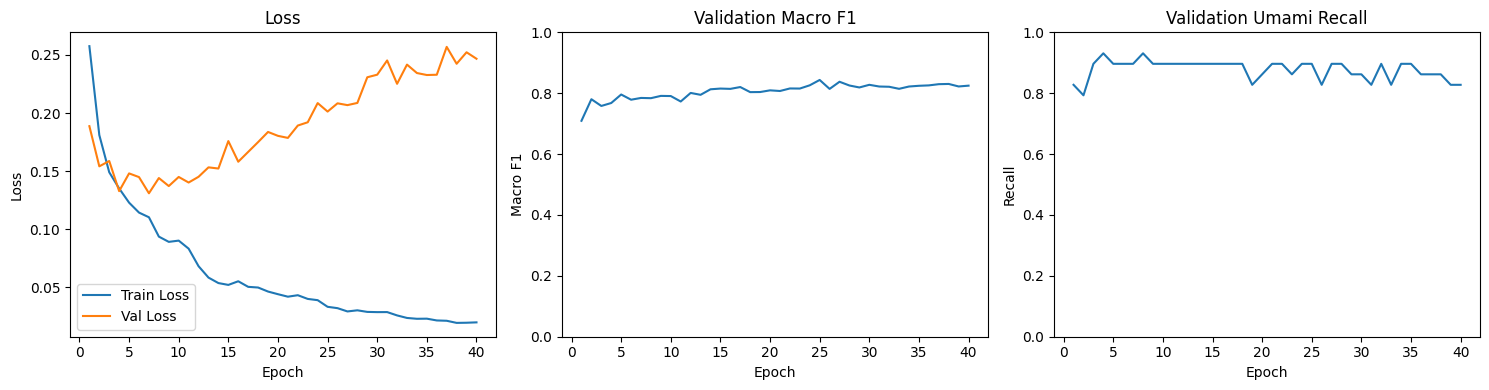

Best undefined threshold on validation: 0.38
Validation Macro-F1 with threshold: 0.8455


In [18]:
# Train model + tune undefined threshold on validation set
print('Training model...')
history, best_f1 = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    device, CLASS_NAMES, num_epochs=100, patience=15
)
print(f"\nBest validation Macro-F1 (argmax): {best_f1:.4f}")
plot_training_history(history)

# Threshold tuning for Undefined prediction rule
val_metrics_raw, y_true_val, y_pred_val_raw, y_prob_val = evaluate_model(
    model, val_loader, criterion, device, CLASS_NAMES, undefined_threshold=None
)

threshold_grid = np.linspace(0.20, 0.90, 29)
best_threshold = 0.50
best_threshold_f1 = -1.0

for th in threshold_grid:
    y_pred_th = apply_undefined_threshold(y_prob_val, th, UNDEFINED_INDEX)
    macro_f1_th = f1_score(y_true_val, y_pred_th, average='macro', zero_division=0)
    if macro_f1_th > best_threshold_f1:
        best_threshold_f1 = macro_f1_th
        best_threshold = float(th)

print(f"Best undefined threshold on validation: {best_threshold:.2f}")
print(f"Validation Macro-F1 with threshold: {best_threshold_f1:.4f}")

## 9. Test Evaluation

In [19]:
# Test set evaluation (thresholded undefined prediction)
test_metrics, y_true_test, y_pred_test, y_prob_test = evaluate_model(
    model,
    test_loader,
    criterion,
    device,
    CLASS_NAMES,
    undefined_threshold=best_threshold,
)

print('Test Results (Macro-F1 focused):')
print(f"  Macro F1:    {test_metrics['macro_f1']:.4f}")
print(f"  Weighted F1: {test_metrics['weighted_f1']:.4f}")
print(f"\nPer-class Recall:")
for name in CLASS_NAMES:
    print(f"  {name}: {test_metrics[f'{name}_Recall']:.4f}")

print(f"\nPer-class F1:")
for name in CLASS_NAMES:
    print(f"  {name}: {test_metrics[f'{name}_F1']:.4f}")

print('\nClassification Report:')
print(classification_report(y_true_test, y_pred_test, target_names=CLASS_NAMES, zero_division=0))

Test Results (Macro-F1 focused):
  Macro F1:    0.8204
  Weighted F1: 0.8815

Per-class Recall:
  Sweet: 0.9130
  Bitter: 0.7885
  Umami: 0.9310
  Sour: 0.9348
  Undefined: 0.7370

Per-class F1:
  Sweet: 0.9413
  Bitter: 0.7381
  Umami: 0.8182
  Sour: 0.8996
  Undefined: 0.7050

Classification Report:
              precision    recall  f1-score   support

       Sweet       0.97      0.91      0.94      1414
      Bitter       0.69      0.79      0.74       227
       Umami       0.73      0.93      0.82        29
        Sour       0.87      0.93      0.90       230
   Undefined       0.68      0.74      0.70       308

    accuracy                           0.88      2208
   macro avg       0.79      0.86      0.82      2208
weighted avg       0.89      0.88      0.88      2208



In [20]:
# Test set class distribution
print("Test set class distribution:")
for i, name in enumerate(CLASS_NAMES):
    count = (y_test == i).sum()
    pred_count = (y_pred_test == i).sum()
    print(f"  {name}: {count} actual, {pred_count} predicted")

Test set class distribution:
  Sweet: 1414 actual, 1329 predicted
  Bitter: 227 actual, 258 predicted
  Umami: 29 actual, 37 predicted
  Sour: 230 actual, 248 predicted
  Undefined: 308 actual, 336 predicted


## 10. Confusion Matrices

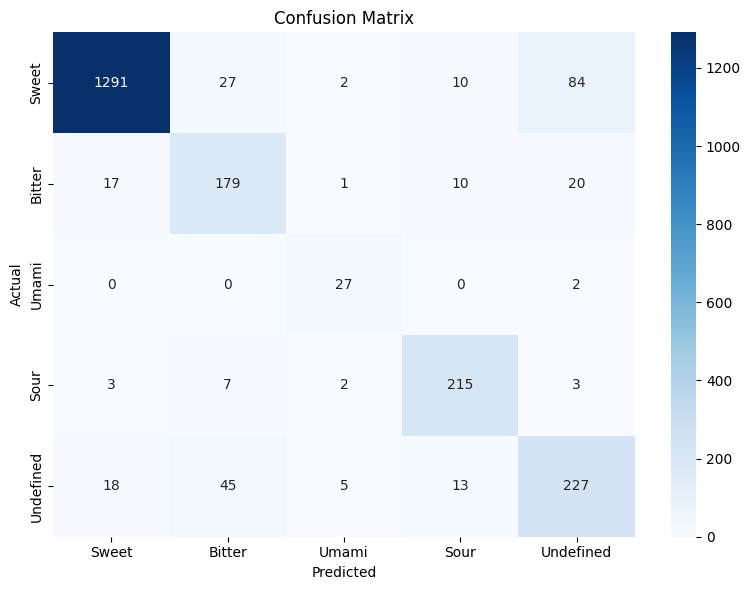

In [21]:
# Confusion matrix
cm = confusion_matrix(y_true_test, y_pred_test)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

## 11. Per-Class Confidence Distribution

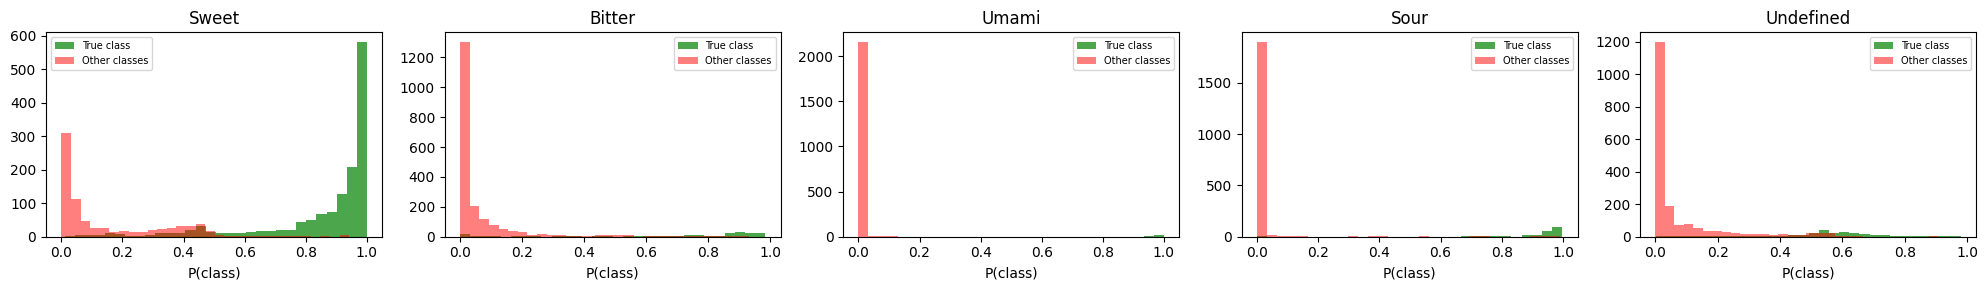

In [22]:
# Per-class predicted probability distributions
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(4 * NUM_CLASSES, 3))
for i, name in enumerate(CLASS_NAMES):
    mask_correct = y_true_test == i
    mask_wrong = y_true_test != i
    if mask_correct.sum() > 0:
        axes[i].hist(y_prob_test[mask_correct, i], bins=30, alpha=0.7, label='True class', color='green')
    if mask_wrong.sum() > 0:
        axes[i].hist(y_prob_test[mask_wrong, i], bins=30, alpha=0.5, label='Other classes', color='red')
    axes[i].set_title(name); axes[i].set_xlabel('P(class)'); axes[i].legend(fontsize=7)
plt.tight_layout()
plt.show()

## 12. Save Model

In [23]:
# Save model
checkpoint = {
    'model_state_dict': model.state_dict(),
    'scalers': scalers,
    'undefined_threshold': best_threshold,
    'config': {
        'mol2vec_dim': MOL2VEC_DIM,
        'chemberta_dim': CHEMBERTA_DIM,
        'rdkit_dim': RDKIT_DIM,
        'num_classes': NUM_CLASSES,
        'dropout_rate': DROPOUT_RATE,
        'focal_gamma': FOCAL_GAMMA,
        'class_names': CLASS_NAMES,
        'undefined_index': UNDEFINED_INDEX,
    }
}

torch.save(checkpoint, 'taste_classifier_model.pth')

with open('taste_mapping.json', 'w') as f:
    json.dump({'classes': CLASS_NAMES, 'undefined_threshold': best_threshold}, f, indent=2)

print('Model saved')

Model saved


## 13. Inference

In [24]:
# Inference function with undefined threshold rule
def predict_taste(mol2vec_feat, chemberta_feat, rdkit_feat, model, scalers, device, undefined_threshold=0.5):
    xm = scalers['mol2vec'].transform(mol2vec_feat.reshape(1, -1))
    xc = scalers['chemberta'].transform(chemberta_feat.reshape(1, -1))
    xr = scalers['rdkit'].transform(rdkit_feat.reshape(1, -1))

    model.eval()
    with torch.no_grad():
        logits = model(
            torch.tensor(xm, dtype=torch.float32).to(device),
            torch.tensor(xc, dtype=torch.float32).to(device),
            torch.tensor(xr, dtype=torch.float32).to(device),
        )
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    predicted_class = int(np.argmax(probs))
    max_prob = float(np.max(probs))

    if max_prob < undefined_threshold:
        predicted_class = UNDEFINED_INDEX

    return {
        'predicted_class': CLASS_NAMES[predicted_class],
        'confidence': max_prob,
        'undefined_threshold': float(undefined_threshold),
        'probabilities': {name: float(probs[i]) for i, name in enumerate(CLASS_NAMES)},
    }


sample_result = predict_taste(
    X_mol2vec[0],
    X_chemberta[0],
    X_rdkit[0],
    model,
    scalers,
    device,
    undefined_threshold=best_threshold,
)
print('Sample prediction:', json.dumps(sample_result, indent=2))

Sample prediction: {
  "predicted_class": "Undefined",
  "confidence": 0.37740084528923035,
  "undefined_threshold": 0.375,
  "probabilities": {
    "Sweet": 0.33192455768585205,
    "Bitter": 0.29035240411758423,
    "Umami": 4.587471266859211e-05,
    "Sour": 0.0002763421507552266,
    "Undefined": 0.37740084528923035
  }
}


## 14. Model Summary

In [25]:
# Model summary
print('Model Summary:')
print('  Task: Single-label multiclass classification (Macro-F1 optimized)')
print(f"  Input branches: Mol2Vec {MOL2VEC_DIM}d -> 256, ChemBERTa {CHEMBERTA_DIM}d -> 256, RDKit {RDKIT_DIM}d -> 128")
print('  Fusion head: 640 -> 512 -> 256 -> 5 logits')
print(f"  Output: {NUM_CLASSES} classes ({', '.join(CLASS_NAMES)})")
print(f"  Loss: FocalLoss(gamma={FOCAL_GAMMA}) + class weights (Undefined downweighted)")
print(f"  Undefined threshold (val-tuned): {best_threshold:.2f}")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model Summary:
  Task: Single-label multiclass classification (Macro-F1 optimized)
  Input branches: Mol2Vec 300d -> 256, ChemBERTa 768d -> 256, RDKit 137d -> 128
  Fusion head: 640 -> 512 -> 256 -> 5 logits
  Output: 5 classes (Sweet, Bitter, Umami, Sour, Undefined)
  Loss: FocalLoss(gamma=2.0) + class weights (Undefined downweighted)
  Undefined threshold (val-tuned): 0.38
  Parameters: 755,205
